In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
column_names = [
    "Sentiment",
    "ID",
    "Date",
    "Query",
    "User",
    "Text"
]
df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    names=column_names
)
display(df.head())
df.info()
print(df.isnull().sum())
print("Dataset Shape:", df.shape)

In [9]:
df = df[["Sentiment", "Text"]]
df = df.sample(n=20000, random_state=42)
df.reset_index(drop=True, inplace=True)
display(df.head())
print(df.shape)

,Sentiment,Text
0,Negative,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,Negative,"@misstoriblack cool , i have no tweet apps fo..."
2,Negative,@TiannaChaos i know just family drama. its la...
3,Negative,School email won't open and I have geography ...
4,Negative,upper airways problem


(20000, 2)



The dataset was reduced to 20,000 randomly selected reviews to improve processing speed while preserving a representative sample for sentiment analysis. Only the **Sentiment** and **Text** columns were retained, as they contain the information required for this project.

In [8]:
df["Sentiment"] = df["Sentiment"].replace({0: "Negative", 4: "Positive"})
display(df.head())
print(df["Sentiment"].value_counts())

,Sentiment,ID,Date,Query,User,Text
0,Negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,Negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,Negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,Negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


Sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64


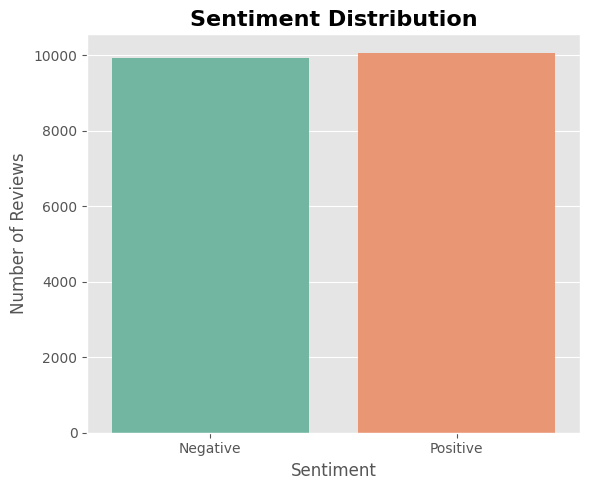

In [10]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df,
    x="Sentiment",
    hue="Sentiment",
    palette="Set2",
    legend=False
)
plt.title("Sentiment Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### Insight
The dataset contains both positive and negative reviews in a balanced distribution. This balanced structure is beneficial for sentiment analysis because it reduces bias toward a single sentiment class and allows for more reliable model evaluation.

In [ ]:
df["Review_Length"] = df["Text"].apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Review_Length"],
    bins=50,
    color="steelblue"
)
plt.title("Distribution of Review Length", fontsize=16, fontweight="bold")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight
Most reviews are relatively short, while only a small number of reviews contain a large amount of text. This indicates that users generally express their opinions using brief comments.

In [ ]:
from wordcloud import WordCloud
positive_text = " ".join(df[df["Sentiment"] == "Positive"]["Text"])
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["Text"])
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(positive_text))
plt.axis("off")
plt.title("Positive Reviews")
plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=800, height=400, background_color="black").generate(negative_text))
plt.axis("off")
plt.title("Negative Reviews")
plt.tight_layout()
plt.show()

### Insight
The word clouds highlight the most frequently used words in positive and negative reviews. Positive reviews commonly contain words expressing satisfaction and appreciation, while negative reviews emphasize complaints and dissatisfaction.

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightcoral", "lightgreen"]
)
plt.title("Sentiment Percentage")
plt.show()

### Insight
The pie chart illustrates the proportion of positive and negative reviews in the dataset. The nearly balanced distribution confirms that the dataset is suitable for sentiment analysis, as both sentiment classes are well represented.

# Final Conclusion
This sentiment analysis project explored customer reviews using Python, Pandas, Matplotlib, Seaborn, and WordCloud. The analysis examined the distribution of positive and negative sentiments, review lengths, and the most frequently used words in customer feedback.
The visualizations showed that the dataset contains a balanced distribution of positive and negative reviews, making it suitable for sentiment analysis. Most reviews were relatively short, indicating that customers generally express their opinions in concise statements. The word clouds highlighted the most common words used in both positive and negative reviews, providing a clear overview of customer opinions and emotions.
Overall, this project demonstrates how sentiment analysis and data visualization techniques can be used to better understand customer feedback and extract meaningful insights from textual data.